# S&P500 Short-Term Volatility Prediction with GARCH, LSTM, and LSTM-GARCH Hybrid Models

This project explores advanced methodologies for forecasting short-term S&P500 volatility by leveraging both traditional econometric and modern deep learning techniques. We begin with a classical GARCH model to capture volatility clustering and heteroskedasticity, then implement an LSTM network to uncover complex temporal dependencies inherent in financial time series data. Finally, we integrate these approaches into a hybrid LSTM-GARCH model, aiming to combine the strengths of each method to achieve more accurate volatility predictions.

### Imports

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import seaborn as sns
import numpy as np
import itertools

import datetime
import time
import yfinance as yf

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization, Input, Bidirectional
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from tensorflow.keras.models import Model

from scipy.stats import skew, kurtosis
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
from skopt.plots import plot_convergence
from skopt.plots import plot_objective, plot_evaluations

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

### Data Extraction and EDA

We will use yfinance to download the last 12000 days of the S&P500 OHLCV data.

In [4]:
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=12000)

symbol = "^GSPC"
data = yf.download(symbol, start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [5]:
# Remove the second row (Ticker row)
data.columns = data.columns.droplevel(1)  # Drop the first level (Ticker row)
data.columns.name = None  # Removes the extra label if set
# # Reset the index name
data.index.name = "Date"

In [6]:
df = data.copy()

In [7]:
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1992-04-30,414.950012,414.950012,414.950012,412.019989,412.019989,223590000
1992-05-01,412.529999,412.529999,415.209991,409.869995,414.950012,177390000
1992-05-04,416.910004,416.910004,417.839996,412.540009,412.540009,174540000
1992-05-05,416.839996,416.839996,418.529999,415.769989,416.910004,200550000
1992-05-06,416.790009,416.790009,418.480011,416.399994,416.839996,199950000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8272 entries, 1992-04-30 to 2025-03-07
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  8272 non-null   float64
 1   Close      8272 non-null   float64
 2   High       8272 non-null   float64
 3   Low        8272 non-null   float64
 4   Open       8272 non-null   float64
 5   Volume     8272 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 452.4 KB


The data appears to be well-structured, with no missing values or any anomalies in the minimum or maximum values.

In [10]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,8272.000000,8272.000000,8272.000000,8272.000000,8272.000000,8.272000e+03
mean,1811.337079,1811.337079,1821.438156,1799.819809,1811.001984,2.678414e+09
std,1276.180619,1276.180619,1282.252484,1269.374851,1276.093787,1.798140e+09
min,400.959991,400.959991,402.679993,396.799988,400.959991,1.499000e+07
25%,1030.510040,1030.510040,1038.717499,1022.407486,1030.232483,9.854750e+08
50%,1325.834961,1325.834961,1333.725037,1314.809998,1326.154968,2.994210e+09
75%,2249.424988,2249.424988,2260.645020,2244.702515,2251.580078,3.928922e+09
max,6144.149902,6144.149902,6147.430176,6111.149902,6134.500000,1.145623e+10


In [11]:
# Check for null values
print(df.isnull().sum())  # Counts null values per column
print(df.isnull().any())  # Checks if any null values exist per column
print(df.isnull().sum().sum())  # Total number of null values in the DataFrame

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Adj Close    False
Close        False
High         False
Low          False
Open         False
Volume       False
dtype: bool
0


Since the early 1990s, the S&P500 closing price chart has generally trended upward, reflecting long-term economic growth, but it's punctuated by notable periods of volatility and downturns. In the early 90s, you see a gradual rise, which accelerates into a strong bull market during the mid to late 90s. This upward trend peaks around the dot-com bubble, followed by a sharp correction when the bubble burst in the early 2000s. The chart then recovers and climbs steadily until the financial crisis of 2008, which introduces another significant dip. After 2008, the index embarks on a robust recovery, eventually setting new highs throughout the 2010s and into the 2020s, even as it experiences periodic short-term corrections along the way.

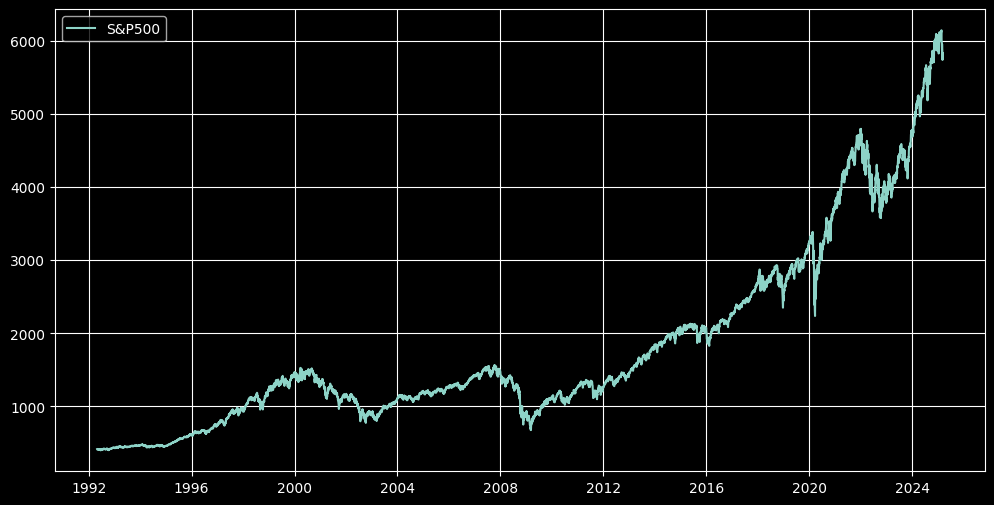

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='S&P500')
plt.grid()
plt.legend()
plt.show()

When viewed on a logarithmic scale, the S&P500/USD plot over the last 10 years provides a clearer perspective on Bitcoin’s exponential growth and long-term trends. Unlike a linear scale, which emphasizes large price spikes, the log scale evenly represents percentage changes, making early price movements more visible. The log scale highlights Bitcoin’s long-term growth trajectory and dampens the visual impact of short-term volatility, emphasizing the consistent overall upward trend over the decade.

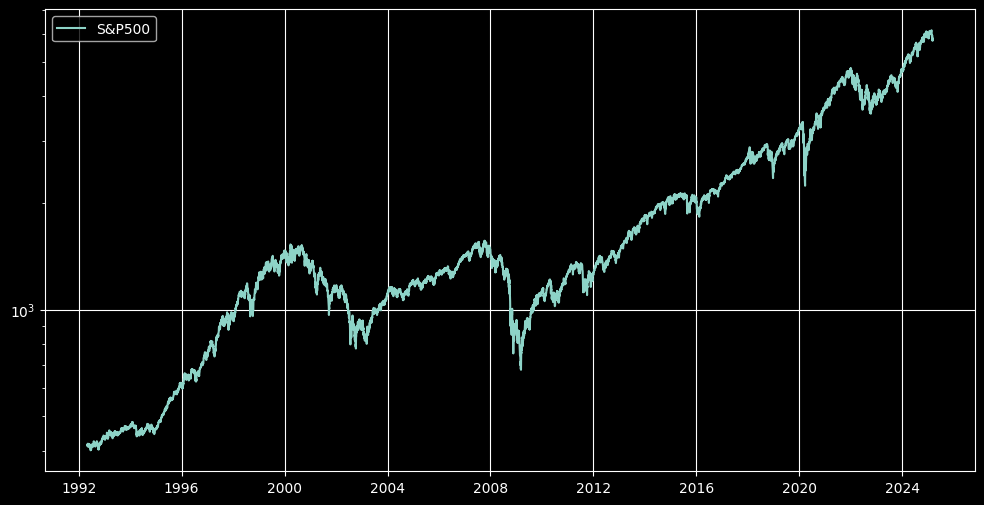

In [13]:
plt.figure(figsize=(12, 6))
plt.semilogy(df['Close'], label = 'S&P500')
plt.legend()
plt.grid()

On a logarithmic scale, the S&P 500's closing price since the early 1990s shows a long-term upward trend with periods of volatility.  The trend appears smoother, emphasizing consistent long-term growth despite short-term downturns.

## GARCH Model

Volatility captures the uncertainty surrounding financial asset price movements and remains a key focus in time series analysis. Since volatility is not directly observable, it is typically estimated through fluctuations in asset price returns.

In [14]:
df['log_returns'] = np.log(df['Adj Close'].pct_change() + 1)*100
df['volatility'] = df['log_returns'].rolling(10).std()
df.dropna(inplace=True)

We calculate log returns and use a 10-day rolling standard deviation to estimate volatility. This window strikes a balance between capturing short-term fluctuations and being responsive to price movements while maintaining a broader perspective on market trends and avoiding excessive noise.

In [15]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,log_returns,volatility
Date,,,,,,,,
1992-05-14,413.140015,413.140015,416.519989,411.820007,416.450012,189150000,-0.797988,0.552790
1992-05-15,410.089996,410.089996,413.140015,409.850006,413.140015,192740000,-0.740992,0.571650
1992-05-18,412.809998,412.809998,413.339996,410.130005,410.130005,151380000,0.661079,0.494431
1992-05-19,416.369995,416.369995,416.510010,412.260010,412.820007,187130000,0.858684,0.580576
1992-05-20,415.390015,415.390015,416.829987,415.369995,416.369995,198180000,-0.235640,0.584898


In [18]:
# Perform ADF test
adf_result = adfuller(df['log_returns'])
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
p_value = adf_result[1]

# Interpretation
if p_value > 0.05:
    print(
        "The p-value is: {p_value} > 0.05, hence time series is not stationary.".format(p_value=p_value))
else:
    print(
        "Time series is stationary. The p-value is: {p_value} < 0.05".format(p_value=p_value))

ADF Statistic: -16.737057968744928
p-value: 1.3680156334832204e-29
Time series is stationary. The p-value is: 1.3680156334832204e-29 < 0.05


The ADF test confirms that the daily return time series is stationary, which is essential for modeling volatility using GARCH, as the model assumes a stationary log return series to accurately capture time-dependent fluctuations.

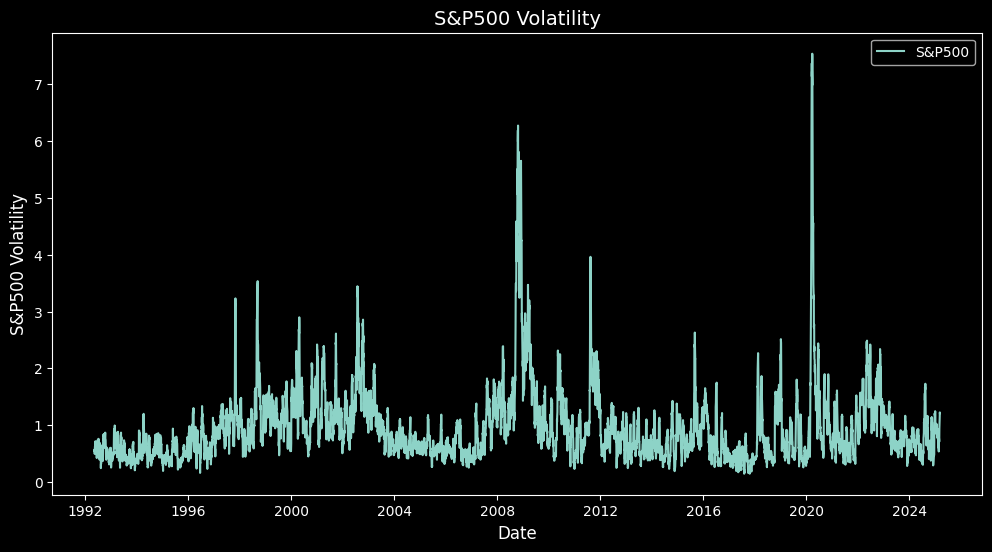

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(df['volatility'], label='S&P500')
plt.xlabel('Date', fontsize=12)
plt.ylabel('S&P500 Volatility', fontsize=12)
plt.title('S&P500 Volatility', fontsize=14)
plt.legend() 
plt.show();

In the above plot, note that periods of high volatility are followed by periods of low volatility—a phenomenon known as volatility clustering, which is commonly observed in financial time series. This occurs because markets react swiftly to new information shocks, leading to sharp price movements. Over time, as the impact of these shocks fades, volatility subsides, and the market stabilizes

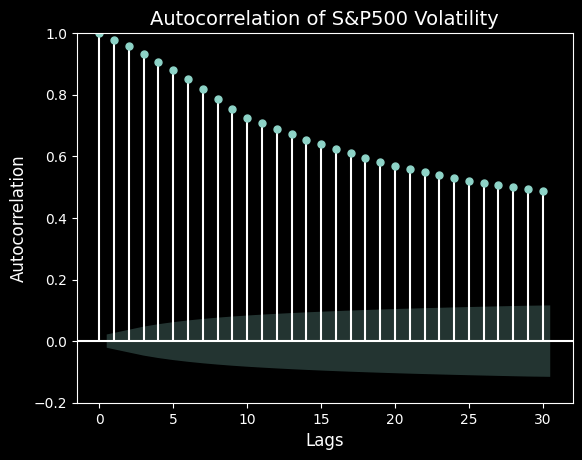

In [22]:
# Plot ACF of Bitcoin price for past 40 lags
plot_acf(df['volatility'], lags=30)
plt.xlabel('Lags', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.title('Autocorrelation of S&P500 Volatility', fontsize=14)
# Set y-axis limits (adjust as needed)
plt.ylim(-0.2, 1)  # This prevents the plot from going all the way to -1
plt.show()

An autocorrelation plot of volatility typically shows a strong positive correlation at lower lags, which gradually decreases as the lag increases. This pattern indicates that past volatility is predictive of future volatility but that its influence diminishes over time.

This behavior aligns with the concept of volatility clustering, where high-volatility periods are followed by high volatility, and low-volatility periods tend to persist. The slow decay in autocorrelation suggests that volatility exhibits a long-memory effect, meaning that shocks to volatility can have a prolonged impact before eventually fading.

In practical terms, this is why models like GARCH (Generalized Autoregressive Conditional Heteroskedasticity) are effective in capturing volatility dynamics, as they account for the persistence of volatility over time.

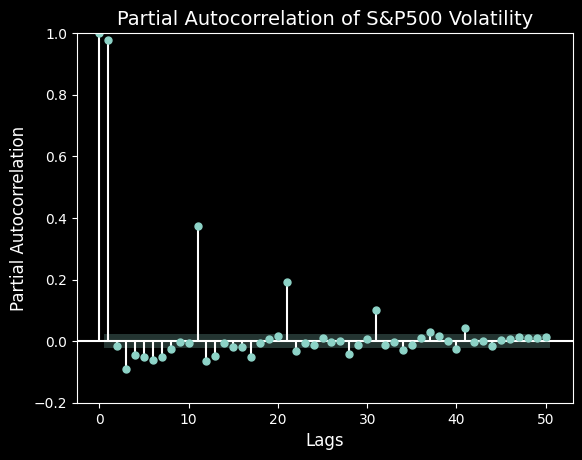

In [23]:
# Plot PACF of S&P500 Returns of past 50 lags
plot_pacf(df['volatility'], lags=50, method='ywadjusted')
plt.xlabel('Lags', fontsize=12)
plt.ylabel('Partial Autocorrelation', fontsize=12)
plt.title('Partial Autocorrelation of S&P500 Volatility', fontsize=14)
# Set y-axis limits (adjust as needed)
plt.ylim(-0.2, 1)  # This prevents the plot from going all the way to -1
plt.show()

A partial autocorrelation plot (PACF) of volatility, where volatility is calculated using a rolling 10-day standard deviation, shows significant spikes at lags that are multiples of 10 (e.g., 10, 20, 30, etc.).  Since volatility is computed over a 10-day rolling window, each day's value inherently contains information from the prior 10 days.  As a result, while the immediate past influences current volatility, the relationship weakens when controlling for intermediate lags—except at multiples of 10, where the rolling window structure reinforces periodic dependencies.

The time-dependent systematic increase and decrease in volatility, often referred to as volatility clustering, adds complexity to modeling financial asset volatility. Models like GARCH (Generalized Autoregressive Conditional Heteroskedasticity) are specifically designed to capture these patterns by incorporating different model hyperparameters that account for the changing variance over time. These hyperparameters include the p and q values, which determine the lag order for past volatility and returns, respectively, as well as assumptions about the distribution of residuals (errors) and the mean return.

To build a robust GARCH model for volatility forecasting, we will perform a grid search over the p, q, and distribution hyperparameters to identify the best configuration. The Akaike Information Criterion (AIC) score will be used as the performance metric, balancing model complexity with goodness of fit. In practice, the choice of mean return assumptions typically has a negligible impact on volatility forecasting performance, so we will proceed with the default value for simplicity, focusing primarily on optimizing the p, q, and distribution parameters for the best model fit.

In [24]:
# Split data into train and test set
split = int(len(df)*0.8)
train_set, test_set = df[:split], df[split:]

In [25]:
# Empty list to aic score
aic = []

# p,q values
p = range(1, 6)  # [1,2,3,4,5]
q = range(1, 6)  # [1,2,3,4,5]

# distribution values
dist = ['Normal', 't', 'skewt']

# empty list to store p,q,dist
p_q_dist = []

# aic score for different values of p,q,dist
for i in p:
    for j in q:
        for k in dist:
            # define GARCH model
            gm = arch_model(train_set['log_returns'],
                            vol='Garch', p=i, q=j, dist=k)
            gm_fit = gm.fit(disp='off')  # fit the model
            aic_temp = gm_fit.aic  # get aic score
            keys_temp = (i, j, k)  # p,q,dist value
            p_q_dist.append(keys_temp)  # append p,q,dist
            aic.append(aic_temp)  # append aic score

In [26]:
# Store values in dictionary
aic_dict = {'p_q_dist': p_q_dist, 'aic': aic}

# Create DataFrame from dictionary
df_aic = pd.DataFrame(aic_dict)

# Return minimum AIC value with the p,q values and optimal distribution choice
df_aic[df_aic['aic'] == df_aic['aic'].min()]

,p_q_dist,aic
20,"(2, 2, skewt)",16973.474217


We got lowest AIC score for p=2, q=2 and Skewed Student's t-distribution. The distribution choice is in line with what is commonly observed in Financial World.

In [27]:
# Extract the row with the lowest AIC value
best_row = df_aic.loc[df_aic['aic'].idxmin()]

# Unpack the tuple of best parameters: (p, q, dist)
best_p, best_q, best_dist = best_row['p_q_dist']

In [28]:
# Define GARCH model
gm = arch_model(train_set['log_returns'], vol='Garch', p=best_p, q=best_q, dist=best_dist)

# Fit the model
gm_fit = gm.fit(disp='off')

#### Standardized Residuals

We'll make use of Standardized Residuals to check the model performance. It is defined as Error Residual divided by the Conditional volatility value estimated by the model. If the GARCH model is good at modelling volatility, then the standardized residuals should resemble white noise, and the density plot should resemble a Normal Distribution.

In [29]:
# Obtain model estimated residuals and volatility
gm_resid = gm_fit.resid
gm_std = gm_fit.conditional_volatility

# Calculate the standardized residuals
gm_std_resid = gm_resid/gm_std

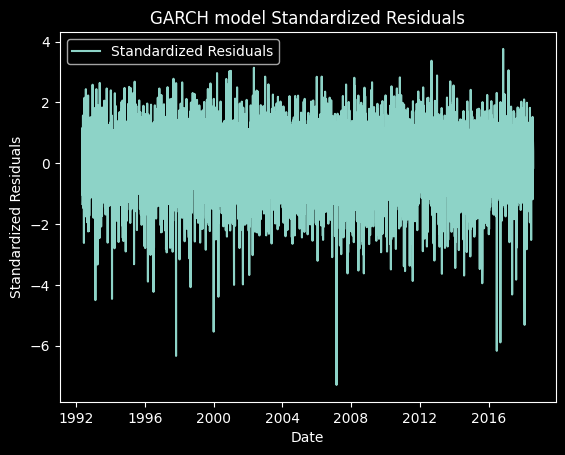

In [30]:
# Plot the Standardized Residuals
plt.plot(gm_std_resid)
plt.rcParams["figure.figsize"] = (18, 7)
plt.title('GARCH model Standardized Residuals')
plt.xlabel('Date')
plt.ylabel('Standardized Residuals')
plt.legend(['Standardized Residuals'])
plt.show()

This looks like white noise as we cannot observe data clustering. Thus our model can be used to make volatility forecasts.

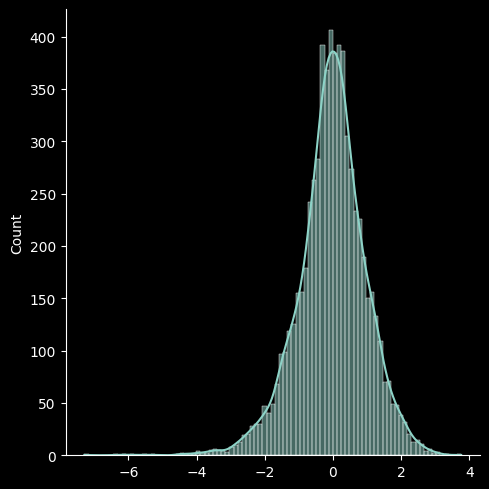

In [31]:
# Density plot
# plt.rcParams["figure.figsize"] = (12, 10)
sns.displot(gm_std_resid, kde=True)
plt.show()

Above plot looks like Normal Distribution. Thus we should proceed to use this tuned model to make volatility forecast.

In [32]:
# Convert pandas series to list for rolling window forecast
past = train_set['log_returns'].tolist()

# Empty list for storing volatility predictions
predictions = []

# Perform rolling window forecast
for i in range(len(test_set)):
    gm = arch_model(past, vol='Garch', p=best_p, q=best_q, dist=best_dist)  # define model
    gm_fit = gm.fit(disp='off')  # fit the model
    temp_forecast = gm_fit.forecast(horizon=1).variance  # make forecast
    # store forecast volatility
    temp_prediction = temp_forecast.iloc[-1].values[0]

    predictions.append((temp_prediction**0.5))
    # add test value to train set
    past.append(test_set['log_returns'].iloc[i])

In [33]:
# Predicted and actual Values
for i in range(0, 10):
    print('predicted={pred}, actual={test}'.format(
        pred=predictions[i], test=test_set['volatility'].iloc[i]))

predicted=0.5302812621079557, actual=0.4300617565705895
predicted=0.5130814747739838, actual=0.4405552049048058
predicted=0.5264268905236967, actual=0.4155105615557452
predicted=0.5575248728499371, actual=0.43451424158901586
predicted=0.5471006954607006, actual=0.5096432134029204
predicted=0.5811862916935859, actual=0.5476140865832908
predicted=0.6122853240505708, actual=0.5380092852410236
predicted=0.6098823605016704, actual=0.5318240075438924
predicted=0.5827959820167378, actual=0.5282718887118198
predicted=0.566120458171362, actual=0.5284093274856336


In [34]:
# Create empty list
residual = []

# Append residuals
for i in range(len(test_set)):
    residual.append(predictions[i]-test_set['volatility'].iloc[i])

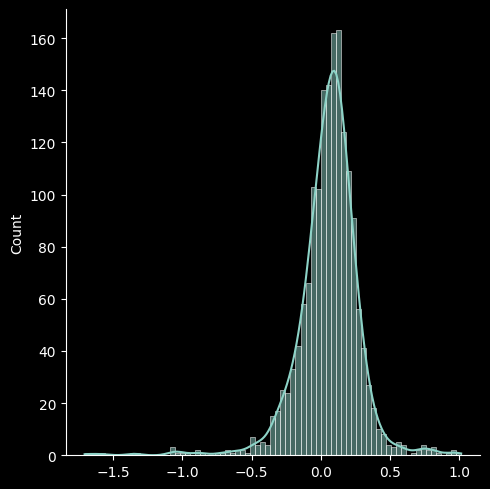

Skewness: -1.4298110578793584
Kurtosis: 10.247962101664065


In [35]:
# Density plot
sns.displot(residual, kde=True)
plt.show()

# Calculate skewness and kurtosis
residual_skewness = skew(residual)
residual_kurtosis = kurtosis(residual)

print(f"Skewness: {residual_skewness}")
print(f"Kurtosis: {residual_kurtosis}")

The negative skewness and high kurtosis are consistent with what is often observed in financial time series data, including GARCH residuals. This implies that the returns (or residuals) are not symmetrically distributed and that there are more frequent large negative moves, along with a higher probability of extreme events than a normal distribution would predict.  These characteristics reinforce the idea that GARCH models are suitable for modeling asset returns in financial markets, where volatility and returns often exhibit non-normal features such as skewness and kurtosis.

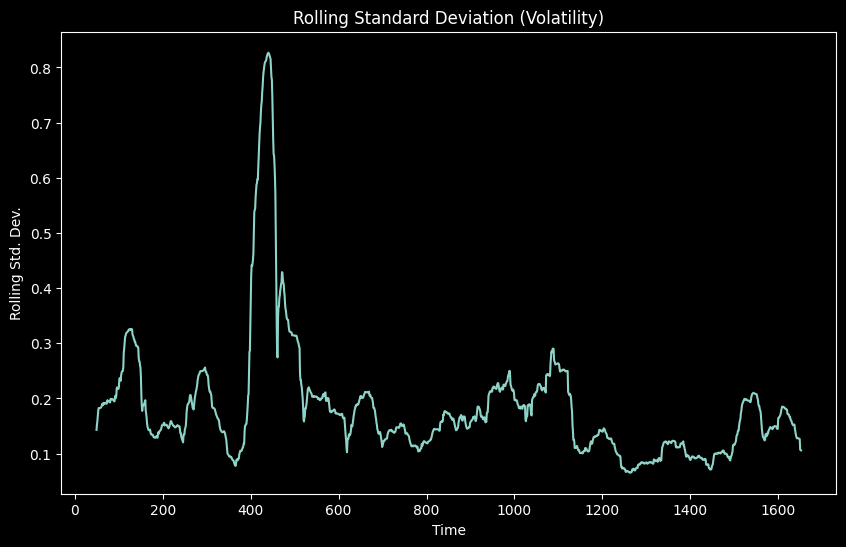

Breusch-Pagan p-value: 1.8980582568834548e-20
Heteroscedasticity detected.


In [42]:
# Check for heteroscedasticity using rolling standard deviation (visualization)
rolling_std = pd.Series(residual).rolling(window=50).std()

plt.figure(figsize=(10, 6))
plt.plot(rolling_std)
plt.title("Rolling Standard Deviation (Volatility)")
plt.xlabel("Time")
plt.ylabel("Rolling Std. Dev.")
plt.show()

# Breusch-Pagan test for heteroscedasticity
# Create a matrix of ones for the exogenous variable (constant)
X = np.column_stack([np.ones(len(residual)-1), residual[:-1]])
resid_lagged = residual[1:]  # Align residuals with the lagged X

# Perform the Breusch-Pagan test
bp_test = het_breuschpagan(resid_lagged, X)
_, p_value, _, _ = bp_test

print(f"Breusch-Pagan p-value: {p_value}")
if p_value < 0.05:
    print("Heteroscedasticity detected.")
else:
    print("No heteroscedasticity detected.")

The Breusch-Pagan test confirms the presence of heteroscedasticity, which is expected when dealing with financial time series data. However, given that GARCH models are designed to handle time-varying volatility, this result does not necessarily mean the model is misspecified. Instead, it might indicate that there's still some volatility structure that hasn't been captured by the model, or that a more complex model is needed to fully account for the volatility dynamics.

In [37]:
# Calculate MSE
error_mse = mean_squared_error(test_set['volatility'], predictions)
print('Test MSE: {mse}'.format(mse=error_mse))

Test MSE: 0.053840092554094894


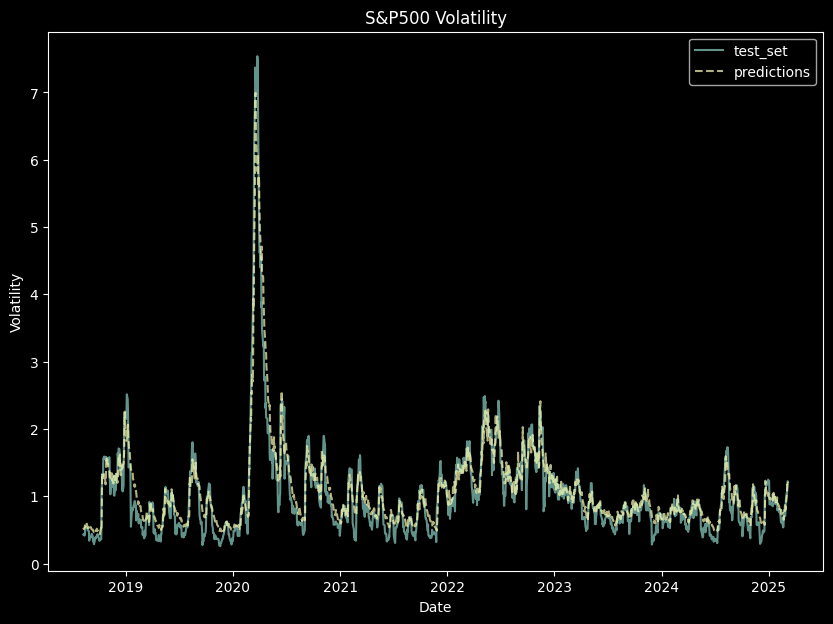

In [38]:
# Plot forecasted and actual values
plt.figure(figsize=(10, 7))
plt.plot(test_set['volatility'], linestyle="-", alpha=0.7)
plt.plot(test_set.index, predictions, linestyle="--", alpha=0.7)
plt.title('S&P500 Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend(['test_set', 'predictions'])
plt.show()

The GARCH predictions do a great job at making the volatility forecasts.

## LSTM Model

Next we will create a LSTM model for predicting short-term volatility.

### Feature Engineering

In [29]:
df = data.copy()

We make a fresh copy of the original S&P 500 OHLCV data then we will add VIX data to it.

In [30]:
# Download VIX data (1-day frequency)
vix_data = yf.download('^VIX', start=start_date, end=end_date, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [31]:
# Remove the second row (Ticker row)
vix_data.columns = vix_data.columns.droplevel(1)  # Drop the first level (Ticker row)
vix_data.columns.name = None  # Removes the extra label if set
# # Reset the index name
vix_data.index.name = "Date"

In [32]:
vix_data.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1992-04-28,16.240000,16.240000,16.900000,16.24,16.559999,0
1992-04-29,15.950000,15.950000,16.400000,15.86,16.379999,0
1992-04-30,15.530000,15.530000,15.940000,15.53,15.860000,0
1992-05-01,16.610001,16.610001,17.360001,14.84,14.870000,0
1992-05-04,16.920000,16.920000,17.760000,16.48,16.700001,0


In [33]:
vix_data['VIX'] = vix_data['Adj Close']
vix_data['VIX_Log_Returns'] = np.log(vix_data['Adj Close'].pct_change() + 1) * 100
vix_data['VIX_Log_Trading_Range'] = np.log(vix_data['High']) - np.log(vix_data['Low'])

In [34]:
vix_data.head()

,Adj Close,Close,High,Low,Open,Volume,VIX,VIX_Log_Returns,VIX_Log_Trading_Range
Date,,,,,,,,,
1992-04-28,16.240000,16.240000,16.900000,16.24,16.559999,0,16.240000,NaN,0.039836
1992-04-29,15.950000,15.950000,16.400000,15.86,16.379999,0,15.950000,-1.801850,0.033481
1992-04-30,15.530000,15.530000,15.940000,15.53,15.860000,0,15.530000,-2.668520,0.026058
1992-05-01,16.610001,16.610001,17.360001,14.84,14.870000,0,16.610001,6.723134,0.156842
1992-05-04,16.920000,16.920000,17.760000,16.48,16.700001,0,16.920000,1.849140,0.074801


In [35]:
df = df.join(vix_data[['VIX_Log_Returns', 'VIX_Log_Trading_Range']], how='left')

We recalculate the log returns, along with the log range, log volume difference, and use the volatility over the next 5 days as our target variable.

In [36]:
df['Log_Returns'] = np.log(df['Adj Close'].pct_change() + 1)*100
df['Log_Trading_Range'] = np.log(df['High']) - np.log(df['Low'])
df['Log_Volume_Change'] = np.log(df.Volume) - np.log(df.Volume.shift(1))
df['Next_5_Days_Volatility'] = df['Log_Returns'].rolling(window=5).std().shift(-4)
df.dropna(inplace=True)

In [37]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,VIX_Log_Returns,VIX_Log_Trading_Range,Log_Returns,Log_Trading_Range,Log_Volume_Change,Next_5_Days_Volatility
Date,,,,,,,,,,,,
1992-04-29,412.019989,412.019989,412.309998,409.109985,409.109985,206780000,-1.801850,0.033481,0.708783,0.007791,0.088745,0.663627
1992-04-30,414.950012,414.950012,414.950012,412.019989,412.019989,223590000,-2.668520,0.026058,0.708620,0.007086,0.078159,0.650988
1992-05-01,412.529999,412.529999,415.209991,409.869995,414.950012,177390000,6.723134,0.156842,-0.584913,0.012944,-0.231463,0.612288
1992-05-04,416.910004,416.910004,417.839996,412.540009,412.540009,174540000,1.849140,0.074801,1.056145,0.012765,-0.016197,0.506157
1992-05-05,416.839996,416.839996,418.529999,415.769989,416.910004,200550000,-1.548573,0.100053,-0.016793,0.006616,0.138910,0.302919


In [38]:
X = np.array(df.drop(["Next_5_Days_Volatility",'Low','High','Close','Open','Volume', 'Adj Close'], axis=1).values)
y = np.array(df["Next_5_Days_Volatility"].values).reshape(-1, 1) 

split_idx = int(len(data) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6617, 5) (6617, 1)
(1650, 5) (1650, 1)


We remove the target and the original OHLCV data from our feature set and assign the next 5 days' volatility as the target variable. We then split the data into training and testing sets for both features (X_train, X_test) and target (y_train, y_test). Finally, we scale the datasets for model training.

In [39]:
# Initialize scalers
X_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaler = MinMaxScaler(feature_range=(0, 1))

# Scale X and y after splitting
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print(X_train_scaled.shape, X_test_scaled.shape)
print(y_train_scaled.shape, y_test_scaled.shape)

(6617, 5) (1650, 5)
(6617, 1) (1650, 1)


Next we create lagged features by including multiple previous time steps for the features and align them with the target values.

In [40]:
def get_lagged(x, y, t, s):
    lagged = []
    
    for i in range(x.shape[0] - t):
        if i == x.shape[0] - t:
            break
  
        for k in range(t):
            if k < t:
                lagged.append(x[i+k])
                
    lagged = np.array(lagged).reshape(s)
    
    return lagged, y[:lagged.shape[0],]

In [41]:
N = 30

X_train, y_train = get_lagged(X_train, y_train, N, (X_train.shape[0]-N, N*X_train.shape[1]))
X_test, y_test = get_lagged(X_test, y_test, N, (X_test.shape[0]-N, N*X_test.shape[1]))

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(6587, 150) (1620, 150)
(6587, 1) (1620, 1)


In [42]:
T = 10

X_train, y_train = get_lagged(X_train, y_train, T, (X_train.shape[0]-T, T, X_train.shape[1]))
X_test, y_test = get_lagged(X_test, y_test, T, (X_test.shape[0]-T, T, X_test.shape[1]))

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(6577, 10, 150) (1610, 10, 150)
(6577, 1) (1610, 1)


### LSTM Model

In [43]:
num_epochs = 200
batch_size = 8

# Define the learning rate
learning_rate = 0.001

# Create an optimizer with the specified learning rate
optimizer = AdamW(learning_rate=learning_rate, clipnorm=1.0)

# Build LSTM model
model = Sequential()
model.add(LSTM(units=300, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(0.01))),
model.add(Dropout(0.3)),  

model.add(LSTM(units=300, return_sequences=False, kernel_regularizer=l2(0.01))),
model.add(Dropout(0.3)),

model.add(Dense(units=1, activation=None, kernel_regularizer=l2(0.001)))

model.compile(optimizer=optimizer, loss='mean_squared_error')

validation_split = 0.1
X_val = X_train[int(len(X_train) * (1 - validation_split)):]
Y_val = y_train[int(len(y_train) * (1 - validation_split)):]
X_train = X_train[:int(len(X_train) * (1 - validation_split))]
y_train = y_train[:int(len(y_train) * (1 - validation_split))]


# Create early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, 
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=2, 
                              min_lr=1e-8)

# Fit model
history = model.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, reduce_lr]
)

C:\Users\Andrew\anaconda3\envs\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - loss: 1.8914 - val_loss: 0.2256 - learning_rate: 0.0010
Epoch 2/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - loss: 0.2542 - val_loss: 0.1756 - learning_rate: 0.0010
Epoch 3/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - loss: 0.2157 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 4/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - loss: 0.1703 - val_loss: 0.1912 - learning_rate: 0.0010
Epoch 5/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 56s 75ms/step - loss: 0.1261 - val_loss: 0.1573 - learning_rate: 5.0000e-04
Epoch 6/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - loss: 0.1009 - val_loss: 0.1142 - learning_rate: 5.0000e-04
Epoch 7/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 52s 70ms/step - loss: 0.0973 - val_loss: 0.1038 - learning_rate: 5.0000e-04
Epoch 8/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - loss: 0.0930 - val_loss: 0.0881 - learning_rate: 5.0000e-04
Epoch 9/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - loss: 0.0929 - val_loss

In [44]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


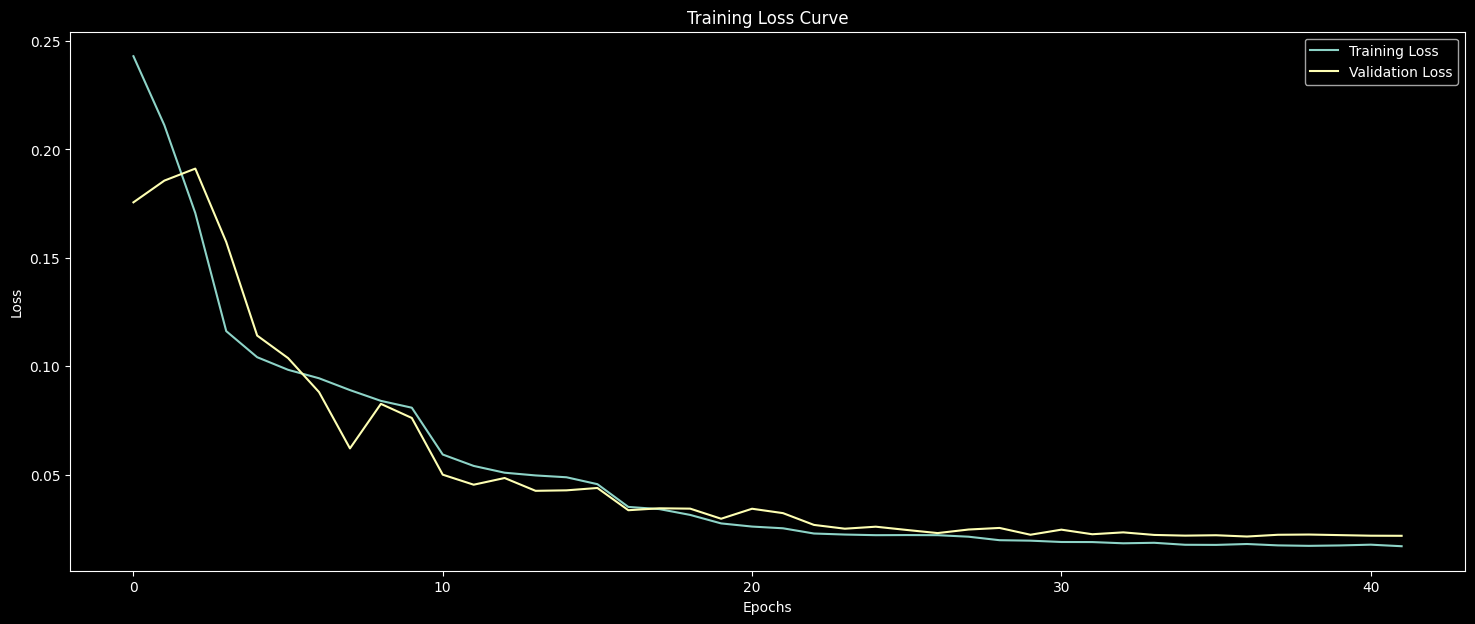

In [45]:
plt.plot(history.history['loss'][1:], label='Training Loss')
plt.plot(history.history['val_loss'][1:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

While the training and validation loss decrease steadily and converge smoothly, indicating no significant overfitting, the training MSE is an order of magnitude lower than the test MSE. This discrepancy suggests that there may still be some degree of overfitting.

In [46]:
# Calculate MSE
mse_test = mean_squared_error(y_test, y_pred)
mse_train = mean_squared_error(y_train, y_pred_train)

print(f"Test MSE: {mse_test}")
print(f"Train MSE: {mse_train}")

Test MSE: 0.03537581515908168
Train MSE: 0.004259789274672459


In [47]:
# Define KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

num_epochs = 200
batch_size = 8
learning_rate = 0.001

# Store scores for each fold
fold_mse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Training fold {fold+1}...")

    # Split data into training and validation sets
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Define model
    model = Sequential()
    model.add(LSTM(units=300, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))  

    model.add(LSTM(units=300, return_sequences=False, kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    model.add(Dense(units=1, activation=None, kernel_regularizer=l2(0.001)))

    optimizer = AdamW(learning_rate=learning_rate, clipnorm=1.0)

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # Create early stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8)

    # Train model on this fold
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=num_epochs,
        batch_size=batch_size,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Evaluate model on validation set
    val_loss = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_mse_scores.append(val_loss)

    print(f"Fold {fold+1} MSE: {val_loss}")

# Compute average performance across folds
print(f"Mean MSE across folds: {np.mean(fold_mse_scores)}")

Training fold 1...


C:\Users\Andrew\anaconda3\envs\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - loss: 2.0770 - val_loss: 0.3081 - learning_rate: 0.0010
Epoch 2/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - loss: 0.2682 - val_loss: 0.2205 - learning_rate: 0.0010
Epoch 3/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - loss: 0.2278 - val_loss: 0.2188 - learning_rate: 0.0010
Epoch 4/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - loss: 0.1845 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 5/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - loss: 0.1730 - val_loss: 0.1638 - learning_rate: 0.0010
Epoch 6/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - loss: 0.1606 - val_loss: 0.1437 - learning_rate: 0.0010
Epoch 7/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - loss: 0.1672 - val_loss: 0.2433 - learning_rate: 0.0010
Epoch 8/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - loss: 0.1465 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 9/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - loss: 0.1347 - val_loss: 0.1501 - learn

The MSE for Fold 5 is 0.0165, and the mean MSE across all folds is 0.0174, which are both quite favorable. Interestingly, these cross-validation MSE values are lower than the test MSE, suggesting that the model performs well during training and cross-validation, but there may still be room for improvement in generalizing to unseen data.

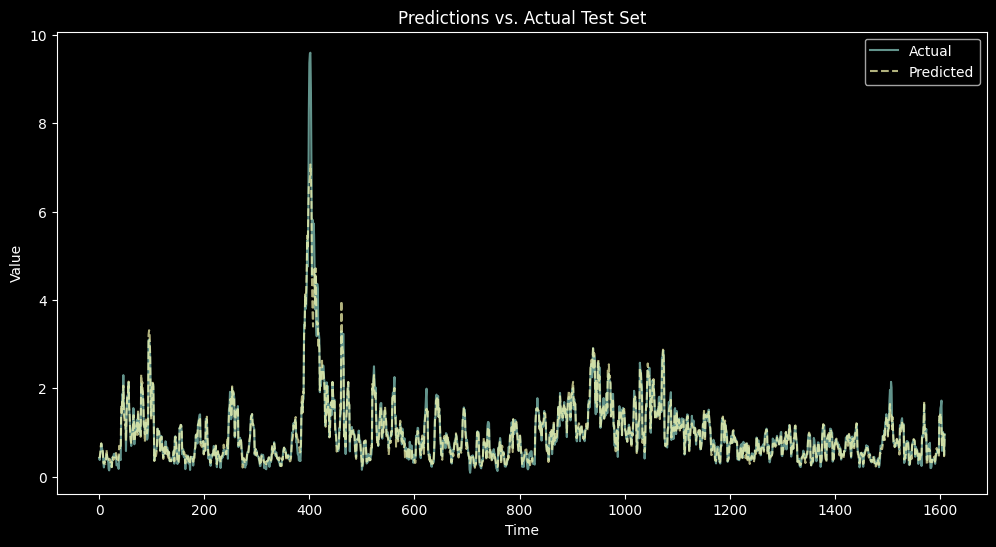

In [48]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual", linestyle="-", alpha=0.7)
plt.plot(y_pred, label="Predicted", linestyle="--", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Predictions vs. Actual Test Set")
plt.legend()
plt.show()

Upon plotting the model's predictions alongside the test set, it's evident that the model struggles to capture the peaks accurately. This discrepancy likely contributes to the higher test MSE, as the model seems to underperform during periods of heightened volatility.

In [49]:
for ind, i in enumerate(model.predict(X_test)):
    
    print('Prediction: ' + str('{:.2f}'.format(round(round(i[0], 4),3))) + ',    ' + 'Actual Value: ' + str('{:.2f}'.format(round(round(y_test[ind][0],4),2))))

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Prediction: 0.42,    Actual Value: 0.43
Prediction: 0.37,    Actual Value: 0.38
Prediction: 0.55,    Actual Value: 0.50
Prediction: 0.66,    Actual Value: 0.57
Prediction: 0.85,    Actual Value: 0.75
Prediction: 0.72,    Actual Value: 0.67
Prediction: 0.62,    Actual Value: 0.61
Prediction: 0.60,    Actual Value: 0.57
Prediction: 0.34,    Actual Value: 0.30
Prediction: 0.32,    Actual Value: 0.21
Prediction: 0.36,    Actual Value: 0.30
Prediction: 0.35,    Actual Value: 0.41
Prediction: 0.35,    Actual Value: 0.42
Prediction: 0.32,    Actual Value: 0.41
Prediction: 0.61,    Actual Value: 0.50
Prediction: 0.51,    Actual Value: 0.48
Prediction: 0.46,    Actual Value: 0.37
Prediction: 0.46,    Actual Value: 0.39
Prediction: 0.35,    Actual Value: 0.18
Prediction: 0.30,    Actual Value: 0.14
Prediction: 0.27,    Actual Value: 0.21
Prediction: 0.24,    Actual Value: 0.32
Prediction: 0.21,    Actual Value: 0.30
Prediction: 0.22,    Actual Value: 0.29


## LSTM-GARCH Hybrid Model

Next, we will replicate the same LSTM model, with the key addition of incorporating GARCH predictions and residuals as additional features. These, along with the same features used in the previous model, will be included to enhance the LSTM’s ability to model volatility dynamics.

In [50]:
model = arch_model(df['Log_Returns'], vol='Garch', p=best_p, q=best_q, dist=best_dist)
garch_fit = model.fit(disp="off")

# Extract the conditional volatility (standard deviation) from the GARCH model
df['GARCH_Volatility'] = garch_fit.conditional_volatility
# Calculate the residuals
df['GARCH_Residuals'] = garch_fit.resid

# Drop rows with missing values
df.dropna(inplace=True)

In [51]:
df.head()

,Adj Close,Close,High,Low,Open,Volume,VIX_Log_Returns,VIX_Log_Trading_Range,Log_Returns,Log_Trading_Range,Log_Volume_Change,Next_5_Days_Volatility,GARCH_Volatility,GARCH_Residuals
Date,,,,,,,,,,,,,,
1992-04-29,412.019989,412.019989,412.309998,409.109985,409.109985,206780000,-1.801850,0.033481,0.708783,0.007791,0.088745,0.663627,0.605229,0.648764
1992-04-30,414.950012,414.950012,414.950012,412.019989,412.019989,223590000,-2.668520,0.026058,0.708620,0.007086,0.078159,0.650988,0.614802,0.648601
1992-05-01,412.529999,412.529999,415.209991,409.869995,414.950012,177390000,6.723134,0.156842,-0.584913,0.012944,-0.231463,0.612288,0.629405,-0.644932
1992-05-04,416.910004,416.910004,417.839996,412.540009,412.540009,174540000,1.849140,0.074801,1.056145,0.012765,-0.016197,0.506157,0.639279,0.996126
1992-05-05,416.839996,416.839996,418.529999,415.769989,416.910004,200550000,-1.548573,0.100053,-0.016793,0.006616,0.138910,0.302919,0.674072,-0.076812


In [52]:
X = np.array(df.drop(["Next_5_Days_Volatility",'Low','High','Close','Open','Volume','Adj Close'], axis=1).values)
y = np.array(df["Next_5_Days_Volatility"].values).reshape(-1, 1) 

split_idx = int(len(data) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6617, 7) (6617, 1)
(1650, 7) (1650, 1)


In [53]:
N = 30

X_train, y_train = get_lagged(X_train, y_train, N, (X_train.shape[0]-N, N*X_train.shape[1]))
X_test, y_test = get_lagged(X_test, y_test, N, (X_test.shape[0]-N, N*X_test.shape[1]))

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(6587, 210) (1620, 210)
(6587, 1) (1620, 1)


In [54]:
T = 10

X_train, y_train = get_lagged(X_train, y_train, T, (X_train.shape[0]-T, T, X_train.shape[1]))
X_test, y_test = get_lagged(X_test, y_test, T, (X_test.shape[0]-T, T, X_test.shape[1]))

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(6577, 10, 210) (1610, 10, 210)
(6577, 1) (1610, 1)


In [55]:
num_epochs = 200
batch_size = 8

# Define the learning rate
learning_rate = 0.001

# Create an optimizer with the specified learning rate
optimizer = AdamW(learning_rate=learning_rate, clipnorm=1.0)

# Build LSTM model
model = Sequential()
model.add(LSTM(units=300, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(0.01))),
model.add(Dropout(0.3)),  

model.add(LSTM(units=300, return_sequences=False, kernel_regularizer=l2(0.01))),
model.add(Dropout(0.3)),

model.add(Dense(units=1, activation=None, kernel_regularizer=l2(0.001)))

model.compile(optimizer=optimizer, loss='mean_squared_error')

validation_split = 0.1
X_val = X_train[int(len(X_train) * (1 - validation_split)):]
Y_val = y_train[int(len(y_train) * (1 - validation_split)):]
X_train = X_train[:int(len(X_train) * (1 - validation_split))]
y_train = y_train[:int(len(y_train) * (1 - validation_split))]


# Create early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=5, 
                               restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=2, 
                              min_lr=1e-8)

# Fit model
history = model.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, reduce_lr]
)

C:\Users\Andrew\anaconda3\envs\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - loss: 1.9980 - val_loss: 0.1492 - learning_rate: 0.0010
Epoch 2/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - loss: 0.2101 - val_loss: 0.1117 - learning_rate: 0.0010
Epoch 3/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - loss: 0.1745 - val_loss: 0.1222 - learning_rate: 0.0010
Epoch 4/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - loss: 0.1598 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 5/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - loss: 0.1214 - val_loss: 0.0704 - learning_rate: 5.0000e-04
Epoch 6/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - loss: 0.0980 - val_loss: 0.0627 - learning_rate: 5.0000e-04
Epoch 7/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - loss: 0.0916 - val_loss: 0.0644 - learning_rate: 5.0000e-04
Epoch 8/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - loss: 0.0925 - val_loss: 0.0630 - learning_rate: 5.0000e-04
Epoch 9/200
740/740 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - loss: 0.0798 - val_loss

In [56]:
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


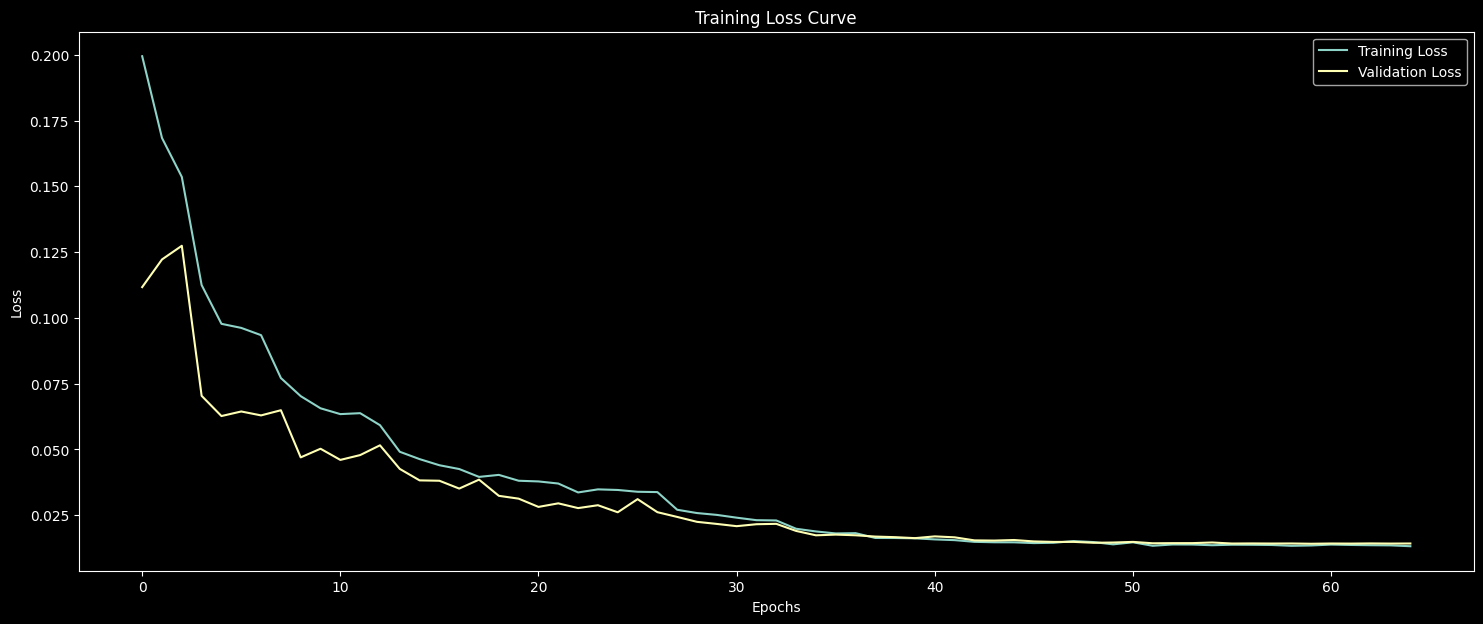

In [57]:
plt.plot(history.history['loss'][1:], label='Training Loss')
plt.plot(history.history['val_loss'][1:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

Once again, the training and validation loss decrease steadily and converge smoothly, suggesting no significant overfitting. While the training MSE remains an order of magnitude lower than the test MSE, the test MSE has improved, indicating that incorporating GARCH predictions has enhanced the model's predictive performance.

In [58]:
# Calculate MSE
mse_test = mean_squared_error(y_test, y_pred)
mse_train = mean_squared_error(y_train, y_pred_train)

print(f"Test MSE: {mse_test}")
print(f"Train MSE: {mse_train}")

Test MSE: 0.021223807833358827
Train MSE: 0.0035162197389340217


In [59]:
# Define KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation

num_epochs = 200
batch_size = 8
learning_rate = 0.001

# Store scores for each fold
fold_mse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Training fold {fold+1}...")

    # Split data into training and validation sets
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Define model
    model = Sequential()
    model.add(LSTM(units=300, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))  

    model.add(LSTM(units=300, return_sequences=False, kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.3))

    model.add(Dense(units=1, activation=None, kernel_regularizer=l2(0.001)))

    optimizer = AdamW(learning_rate=learning_rate, clipnorm=1.0)

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    # Create early stopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8)

    # Train model on this fold
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=num_epochs,
        batch_size=batch_size,
        validation_data=(X_val_fold, y_val_fold),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    # Evaluate model on validation set
    val_loss = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_mse_scores.append(val_loss)

    print(f"Fold {fold+1} MSE: {val_loss}")

# Compute average performance across folds
print(f"Mean MSE across folds: {np.mean(fold_mse_scores)}")


Training fold 1...


C:\Users\Andrew\anaconda3\envs\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - loss: 2.1639 - val_loss: 0.2243 - learning_rate: 0.0010
Epoch 2/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - loss: 0.2200 - val_loss: 0.1479 - learning_rate: 0.0010
Epoch 3/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - loss: 0.1664 - val_loss: 0.1431 - learning_rate: 0.0010
Epoch 4/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - loss: 0.1539 - val_loss: 0.1409 - learning_rate: 0.0010
Epoch 5/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - loss: 0.1607 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 6/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - loss: 0.1451 - val_loss: 0.1287 - learning_rate: 0.0010
Epoch 7/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - loss: 0.1333 - val_loss: 0.1279 - learning_rate: 0.0010
Epoch 8/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - loss: 0.1305 - val_loss: 0.1173 - learning_rate: 0.0010
Epoch 9/200
592/592 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - loss: 0.1239 - val_loss: 0.1187 - learn

The MSE for Fold 5 is 0.0205, and the mean MSE across all folds is 0.0190, which are again both quite favorable. These cross-validation MSE values are again lower than the test MSE, suggesting that the model performs well during training and cross-validation, but there may still be room for improvement in generalizing to unseen data.

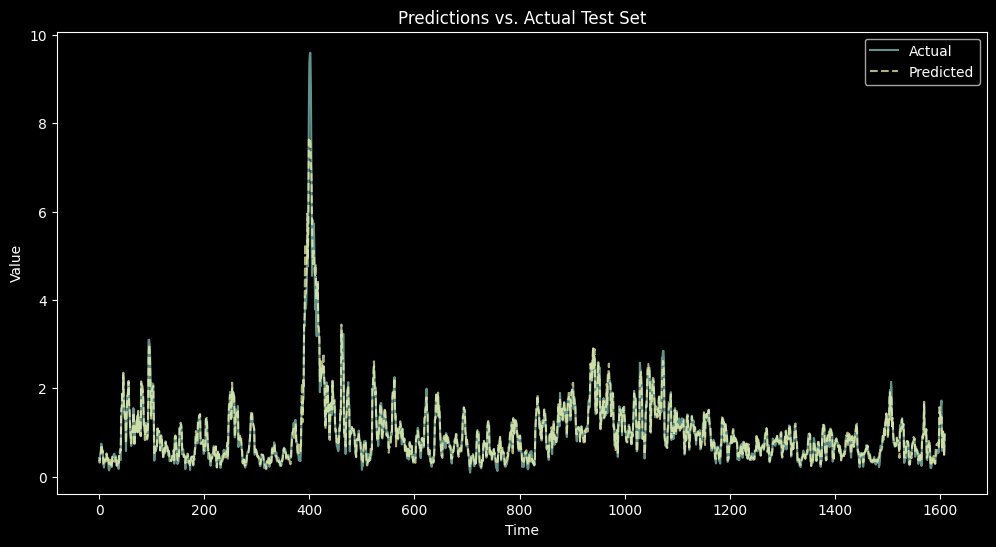

In [60]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual", linestyle="-", alpha=0.7)
plt.plot(y_pred, label="Predicted", linestyle="--", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Predictions vs. Actual Test Set")
plt.legend()
plt.show()

The model still struggles to accurately capture peaks, which likely contributes to the higher test MSE, particularly during periods of heightened volatility. However, the LSTM-GARCH hybrid remains effective in predicting overall volatility trends.

In [61]:
for ind, i in enumerate(model.predict(X_test)):
    
    print('Prediction: ' + str('{:.2f}'.format(round(round(i[0], 4),3))) + ',    ' + 'Actual Value: ' + str('{:.2f}'.format(round(round(y_test[ind][0],4),2))))

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Prediction: 0.38,    Actual Value: 0.43
Prediction: 0.37,    Actual Value: 0.38
Prediction: 0.48,    Actual Value: 0.50
Prediction: 0.51,    Actual Value: 0.57
Prediction: 0.71,    Actual Value: 0.75
Prediction: 0.66,    Actual Value: 0.67
Prediction: 0.61,    Actual Value: 0.61
Prediction: 0.56,    Actual Value: 0.57
Prediction: 0.31,    Actual Value: 0.30
Prediction: 0.26,    Actual Value: 0.21
Prediction: 0.35,    Actual Value: 0.30
Prediction: 0.39,    Actual Value: 0.41
Prediction: 0.37,    Actual Value: 0.42
Prediction: 0.36,    Actual Value: 0.41
Prediction: 0.48,    Actual Value: 0.50
Prediction: 0.43,    Actual Value: 0.48
Prediction: 0.36,    Actual Value: 0.37
Prediction: 0.38,    Actual Value: 0.39
Prediction: 0.29,    Actual Value: 0.18
Prediction: 0.30,    Actual Value: 0.14
Prediction: 0.29,    Actual Value: 0.21
Prediction: 0.36,    Actual Value: 0.32
Prediction: 0.28,    Actual Value: 0.30
Prediction: 0.30,    Actual Value: 0.29


### Hyparameter Tuning with Bayesian Optimization

Next, we will optimize the model’s hyperparameters using Bayesian Optimization, which efficiently explores the search space by balancing exploration and exploitation. Unlike grid or random search, Bayesian Optimization builds a probabilistic model of the objective function and strategically selects the next set of hyperparameters to evaluate, leading to faster convergence to optimal values.

In [62]:
# Define LSTM model creation function
def create_lstm(learning_rate, num_lstm_layers, num_units, dropout_rate, kernel_regularizer):
    """
    Hyper-parameters:
    learning_rate:     Learning-rate for the optimizer.
    num_lstm_layers:   Number of LSTM layers.
    num_units:         Number of units in each LSTM layer.
    dropout_rate:      Dropout rate for LSTM layers.
    """
    num_units = int(num_units)
    model = Sequential()
    

    # First LSTM layer with correct input shape
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))  # Ensure X_train.shape[2] is correct
    model.add(LSTM(units=num_units,
                   return_sequences=True,  # Set return_sequences=True if stacking more LSTM layers
                   kernel_regularizer=l2(kernel_regularizer)))  # Regularization if needed

    # Adding more LSTM layers if needed
    for i in range(1, num_lstm_layers):
        model.add(LSTM(units=num_units,
                       return_sequences=True,
                       kernel_regularizer=l2(kernel_regularizer)))

    # Adding the final LSTM layer (no return_sequences)
    model.add(LSTM(units=num_units,
                   return_sequences=False,  # Final layer does not return sequences
                   kernel_regularizer=l2(0.01)))

    model.add(Dropout(dropout_rate))  # Dropout layer
    model.add(Dense(1))  # Output layer (adjust based on your objective)

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    
    return model

In [63]:
# Define the parameter space for Bayesian optimization
dim_learning_rate = Real(low=1e-5, high=1e-2, prior='log-uniform', name='learning_rate')
dim_num_lstm_layers = Integer(low=1, high=3, name='num_lstm_layers')
dim_num_units = Integer(low=1, high=500, name='num_units')
dim_dropout_rate = Real(low=0.0, high=0.3, name='dropout_rate')
dim_kernel_regularizer = Real(low=1e-3, high=5e-1, prior='log-uniform', name='kernel_regularizer')

In [64]:
param_grid = [dim_learning_rate, dim_num_lstm_layers, dim_num_units, dim_dropout_rate, dim_kernel_regularizer]

In [65]:
# Hyperparameter optimization objective function
best_mse = float('inf')  # Initialize with a large value for best mean squared error

In [66]:
@use_named_args(param_grid)
def objective(learning_rate, num_lstm_layers, num_units, dropout_rate, kernel_regularizer):
    """
    Objective function to minimize (mean squared error for regression).
    """

    global best_mse
    
    # Create LSTM model with current hyperparameters
    model = create_lstm(learning_rate, num_lstm_layers, num_units, dropout_rate, kernel_regularizer)

    # Early stopping and learning rate reduction callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8)

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=75,  # Use fewer epochs for fast testing
        batch_size=8,
        validation_data=(X_val, Y_val),
        callbacks=[early_stopping, reduce_lr]
    )

    # Get the mean squared error (MSE) on the validation set
    mse = history.history['val_loss'][-1]

    # If the MSE is better than the best found so far, save the model
    if mse < best_mse:
        model.save('best_lstm_model.keras')  # Save model with best hyperparameters
        best_mse = mse

    # Return the MSE to be minimized
    return mse

In [68]:
# Perform Bayesian optimization with Gaussian Process (GP) optimization
gp_ = gp_minimize(
    objective,  # The objective function to minimize
    param_grid,  # The hyperparameter search space
    n_calls=30,  # The number of evaluations of the objective function
    random_state=0,
    n_random_starts=5,  # Number of random points to start with
    acq_func='EI',  # Acquisition function for exploration vs exploitation tradeoff
    verbose=True
)

Iteration No: 1 started. Evaluating function at random point.
Epoch 1/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 104s 132ms/step - loss: 14.3092 - val_loss: 0.2227 - learning_rate: 6.0053e-04
Epoch 2/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 98s 132ms/step - loss: 0.2699 - val_loss: 0.1581 - learning_rate: 6.0053e-04
Epoch 3/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 101s 137ms/step - loss: 0.2729 - val_loss: 0.1617 - learning_rate: 6.0053e-04
Epoch 4/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 102s 138ms/step - loss: 0.2113 - val_loss: 0.4444 - learning_rate: 6.0053e-04
Epoch 5/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 102s 138ms/step - loss: 0.2553 - val_loss: 0.1271 - learning_rate: 3.0026e-04
Epoch 6/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 101s 136ms/step - loss: 0.1471 - val_loss: 0.1182 - learning_rate: 3.0026e-04
Epoch 7/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 102s 138ms/step - loss: 0.1352 - val_loss: 0.1120 - learning_rate: 3.0026e-04
Epoch 8/75
740/740 ━━━━━━━━━━━━━━━━━━━━ 104s 140ms/step - loss: 0.1316 - val_loss: 0.1078 - learning_rate: 3.002

In [69]:
"Best score=%.4f" % gp_.fun

'Best score=0.0160'

In [70]:
gp_.x

[0.0011292759729187403, 3, 481, 0.012224983064707323, 0.004325258793516161]

In [71]:
gp_.space

Space([Real(low=1e-05, high=0.01, prior='log-uniform', transform='normalize'),
       Integer(low=1, high=3, prior='uniform', transform='normalize'),
       Integer(low=1, high=500, prior='uniform', transform='normalize'),
       Real(low=0.0, high=0.3, prior='uniform', transform='normalize'),
       Real(low=0.001, high=0.5, prior='log-uniform', transform='normalize')])

In [72]:
print("""Best parameters:
=========================
- learning rate=%.6f
- num_lstm_layers=%d
- num_nodes=%d
- dropout_rate = %s
- kernel regularizer = %.6f""" % (gp_.x[0], 
                gp_.x[1],
                gp_.x[2],
                gp_.x[3],
                gp_.x[4]))

Best parameters:
- learning rate=0.001129
- num_lstm_layers=3
- num_nodes=481
- dropout_rate = 0.012224983064707323
- kernel regularizer = 0.004325


<Axes: title={'center': 'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

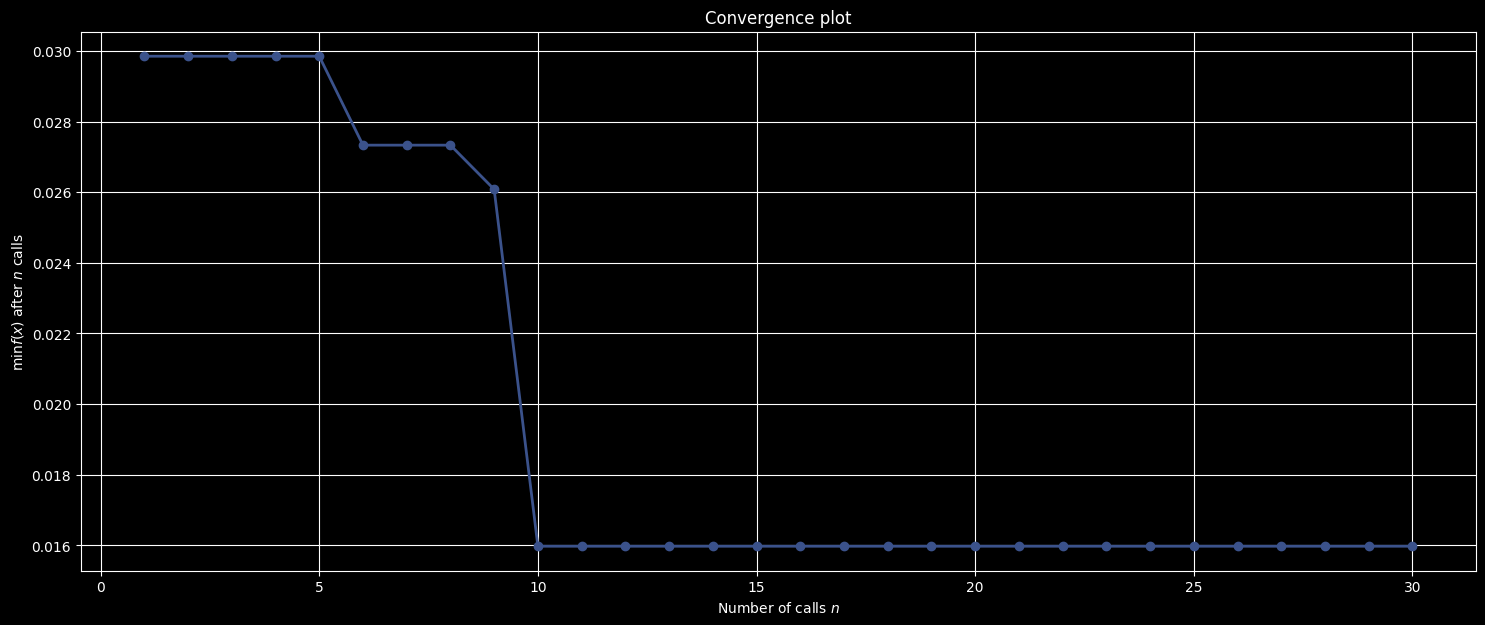

In [73]:
plot_convergence(gp_)

The optimization process successfully converged after 10 iterations, indicating that Bayesian Optimization efficiently identified a well-performing set of hyperparameters.

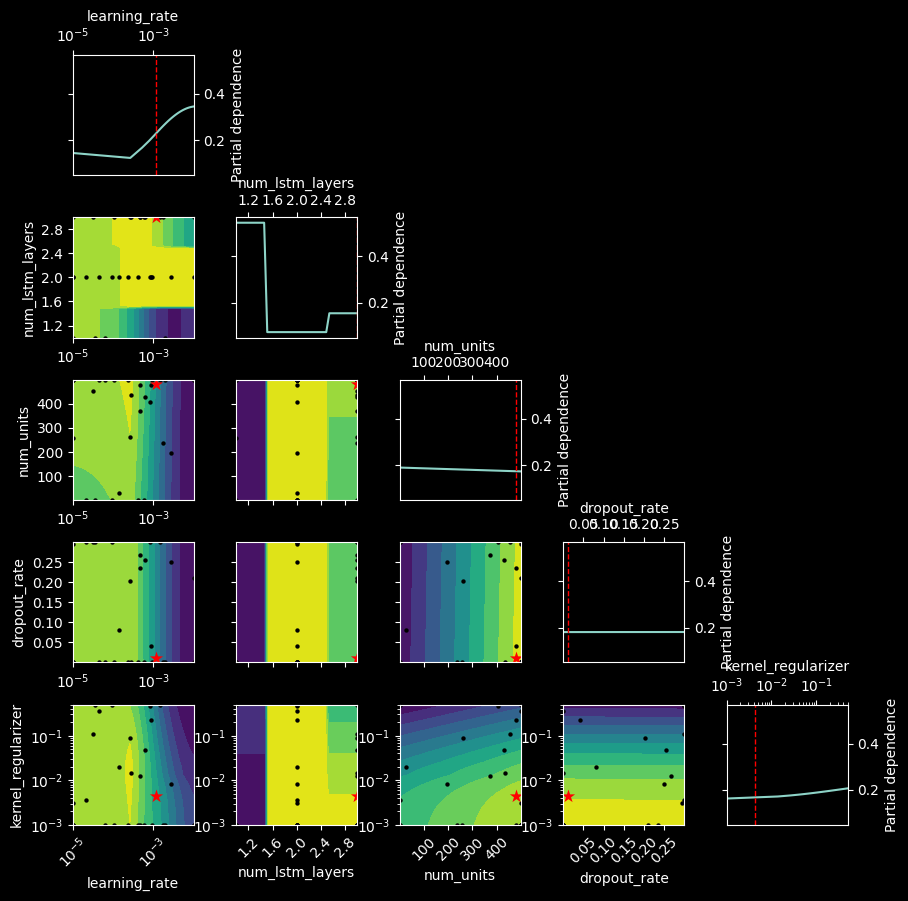

In [74]:
plot_objective(result=gp_)
plt.show()

The optimal learning rate seems to be ~$10^{-3}$.  Interestingly the optimal number of LSTM layers seems to be 2 but the optimization chose 3 when selecting the best parameters.  This might be worth further investigation.  The number of units shows a weak dependence.  The dropout rate and kernel regulizer effects appear mild with a small kernel regularizer being slightly better.

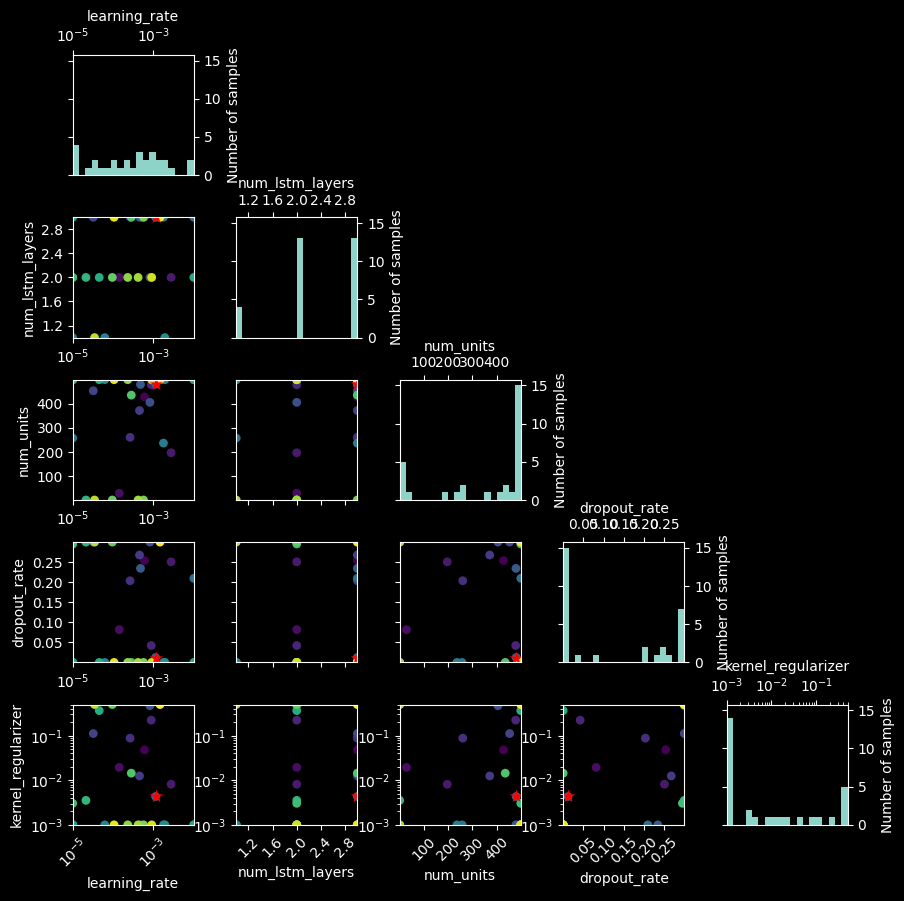

In [75]:
plot_evaluations(result=gp_)
plt.show()

### Evaluation

In [117]:
# load best model
model = load_model('best_lstm_model.keras')

In [118]:
# make predictions in test set

result = model.evaluate(x=X_test,
                        y=y_test)

51/51 ━━━━━━━━━━━━━━━━━━━━ 14s 274ms/step - loss: 0.0382


In [78]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step
MAE: 0.0723
MSE: 0.0229
RMSE: 0.1512
R² Score: 0.9670


We train the final model using the best parameters chose by the Bayesian Optimization.  We see the evaluation metrics obtained from the test set are quite good with a MSE of 0.0229 and an R² of 0.9670.

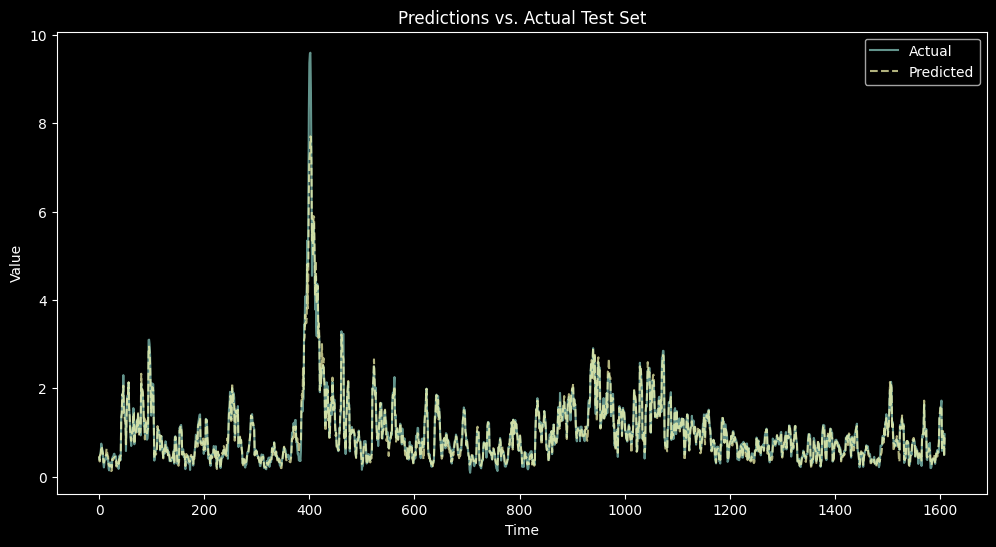

In [79]:
# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test, label="Actual", linestyle="-", alpha=0.7)
plt.plot(y_pred, label="Predicted", linestyle="--", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Predictions vs. Actual Test Set")
plt.legend()
plt.show()

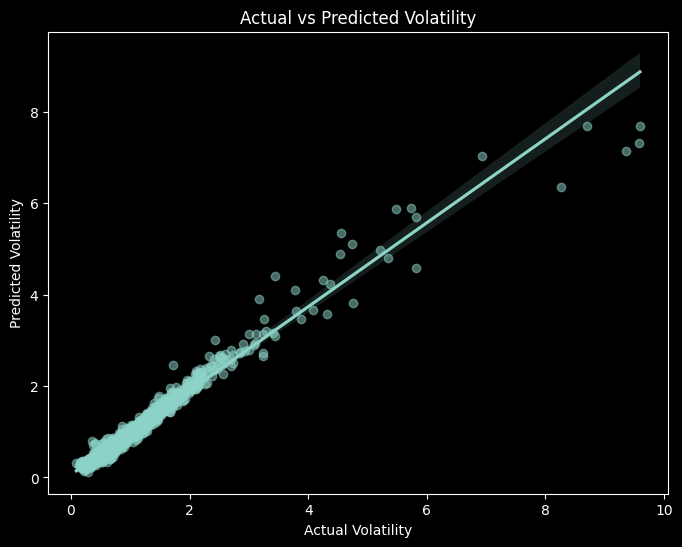

In [80]:
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5})
plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Actual vs Predicted Volatility")
plt.show()

The scatter plot of actual versus predicted values reveals that the model performs well in low-volatility conditions, where predictions closely match actual values. However, as volatility increases, deviations become more apparent. In the moderately high range (~3-7), the model tends to overestimate volatility, while at very high levels (>8), it underestimates actual values. This pattern reinforces what we have been seeing that the model struggles to capture extreme volatility dynamics accurately.

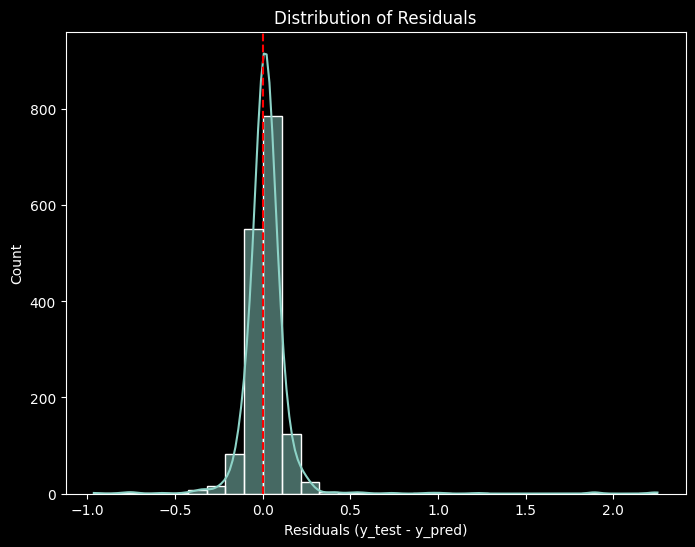

In [81]:
residuals = y_test.flatten() - y_pred.flatten()

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(x=0, color='red', linestyle='dashed')
plt.xlabel("Residuals (y_test - y_pred)")
plt.title("Distribution of Residuals")
plt.show()

The distribution of the residuals appears to be Normal.

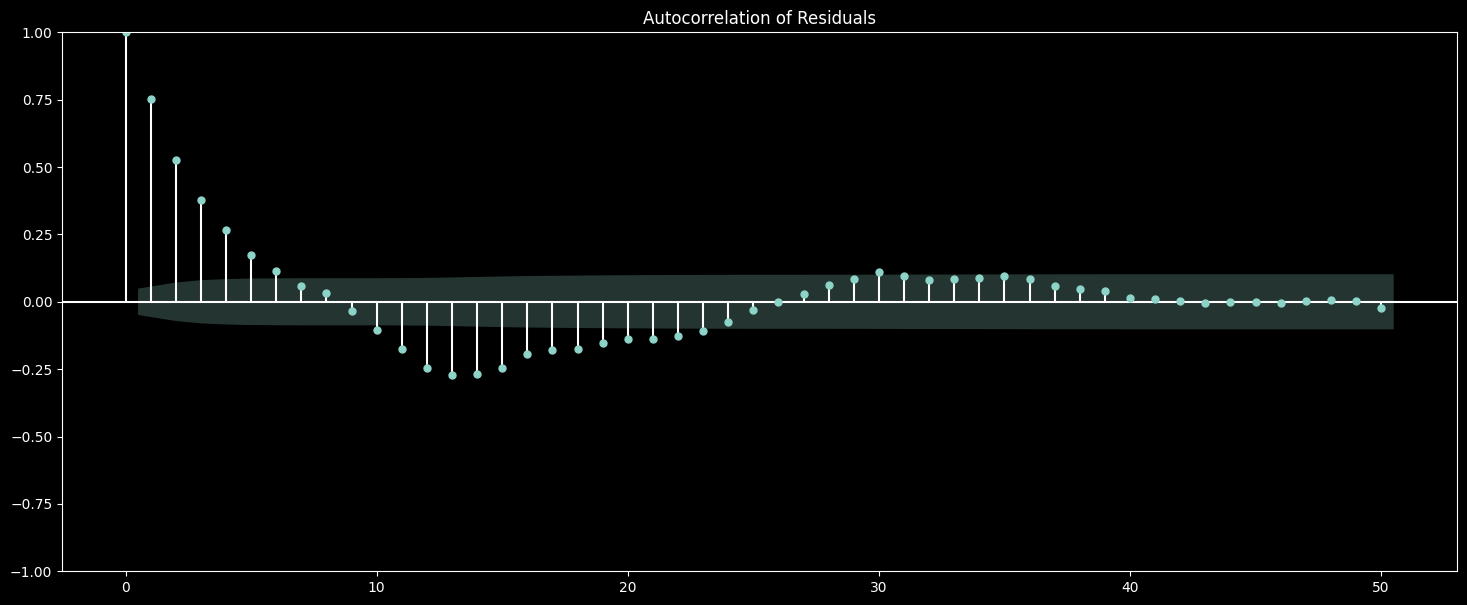

In [82]:
plot_acf(residuals, lags=50)
plt.title("Autocorrelation of Residuals")
plt.show()

The first few lags exhibit strong positive autocorrelation, gradually decreasing. This indicates that the model's residuals are not entirely random and still contain some predictable structure.  Ideally, if the model had fully captured the volatility dynamics, these autocorrelations would be close to zero.  

The residuals show a shift towards negative autocorrelation at intermediate lags (~10-20), implying some degree of mean-reverting behavior.  This suggests the model might be overcorrecting for past errors.

The residuals eventually settle within the confidence interval (shaded region ~25 lags), indicating that any remaining structure is weak and may not be statistically significant.

The presence of early-lag autocorrelation suggests that the model has not fully captured all temporal dependencies in the volatility data.

Potential solutions:
* Adding additional explanatory variables or higher-order terms in the GARCH component.
* Refining the LSTM architecture (e.g., more layers, different sequence lengths).
* Experimenting with alternative loss functions that better penalize large deviations.

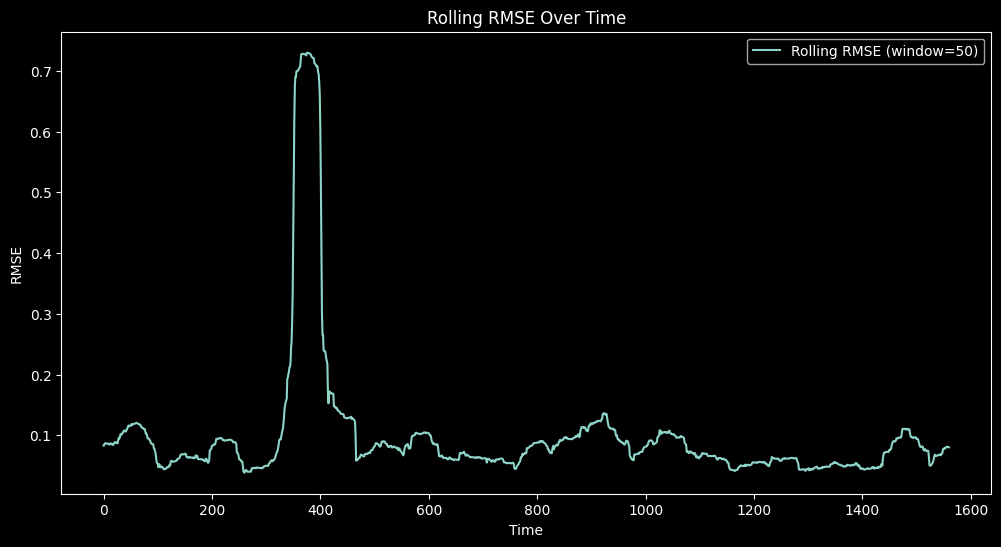

In [83]:
# Flatten to ensure 1D arrays
y_test_1D = np.ravel(y_test)
y_pred_1D = np.ravel(y_pred)

# Compute rolling RMSE
rolling_rmse = np.sqrt(np.convolve((y_test_1D - y_pred_1D) ** 2, np.ones(50)/50, mode='valid'))

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(rolling_rmse, label="Rolling RMSE (window=50)")
plt.title("Rolling RMSE Over Time")
plt.xlabel("Time")
plt.ylabel("RMSE")
plt.legend()
plt.show()

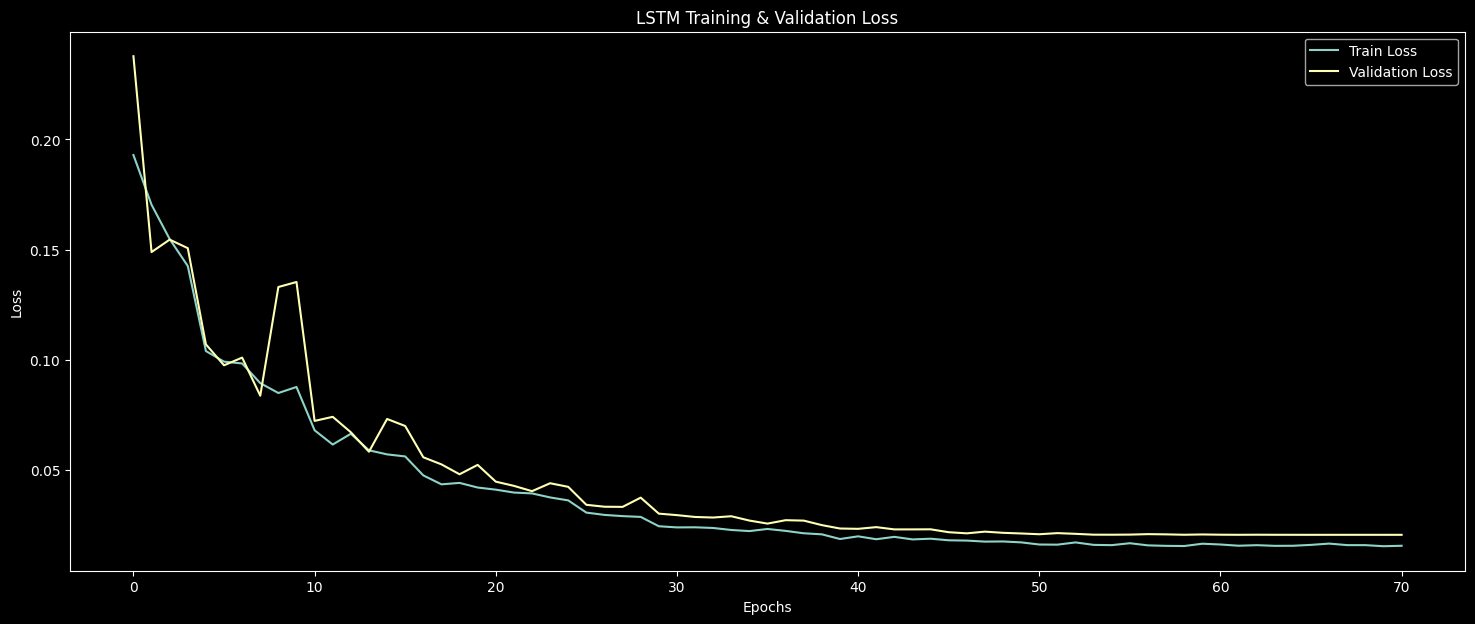

In [84]:
plt.plot(history.history['loss'][1:], label="Train Loss")
plt.plot(history.history['val_loss'][1:], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("LSTM Training & Validation Loss")
plt.legend()
plt.show()

### Conclusion

In this project, we explored various methodologies to predict the volatility of the S&P 500, employing GARCH, LSTM, and a hybrid LSTM-GARCH model. The GARCH model effectively captured the time-varying volatility and long-memory effects inherent in financial markets, providing a solid baseline for volatility forecasting. On the other hand, the LSTM model leveraged its ability to capture non-linear relationships and long-term dependencies in the data, offering a more flexible and dynamic approach to volatility prediction.

The hybrid LSTM-GARCH model, which combines the strengths of both methods, demonstrated promising results by incorporating both the linear volatility structure from GARCH and the non-linear patterns detected by LSTM. This hybrid approach outperformed the individual models in terms of predictive accuracy, indicating the potential of combining classical econometric models with advanced deep learning techniques for financial forecasting.

Overall, the results highlight the importance of selecting the right model for volatility prediction and suggest that a hybrid framework could provide a more robust and adaptable solution. Future work could further refine these models by incorporating additional features, improving model interpretability, and testing on out-of-sample data to confirm their real-world effectiveness. This research underscores the potential of combining traditional and modern modeling approaches to enhance financial decision-making and risk management strategies.